# Meta-Analysis of JRN Probe Reliability

**Heterogeneity Decomposition and Practitioner Guidelines**

This notebook demonstrates a meta-evaluation that pools 280 JRN (Join Reproduction Number) measurements
from 7 experiments across 4 datasets (rel-f1, rel-stack, rel-avito, rel-hm). It computes:

1. **Pooled JRN statistics** (mean, beneficial fraction, threshold proximity)
2. **Probe-vs-GT error metrics** (sign agreement, absolute/relative error, Spearman ρ)
3. **GBM meta-model** predicting probe error from schema features
4. **Depth-2 decision rules** for practitioner guidance
5. **Training-free proxy reliability** (5 proxies with per-dataset Spearman ρ and selection AUC)
6. **Proxy selection decision tree** mapping schema features to best estimation method
7. **Heterogeneity decomposition** (I², Cochran's Q, τ², within/between-dataset breakdown)

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# Core packages — pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    try:
        _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0')
    except Exception:
        # Fallback for Python <3.12 where Colab-exact versions are unavailable
        _pip('numpy', 'pandas', 'scikit-learn', 'scipy', 'matplotlib')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


ERROR: Ignored the following versions that require a different python version: 1.16.0 Requires-Python >=3.11; 1.16.0rc1 Requires-Python >=3.11; 1.16.0rc2 Requires-Python >=3.11; 1.16.1 Requires-Python >=3.11; 1.16.2 Requires-Python >=3.11; 1.16.3 Requires-Python >=3.11; 1.17.0 Requires-Python >=3.11; 1.17.0rc1 Requires-Python >=3.11; 1.17.0rc2 Requires-Python >=3.11; 1.17.1 Requires-Python >=3.11; 1.6.2 Requires-Python >=3.7,<3.10; 1.6.3 Requires-Python >=3.7,<3.10; 1.7.0 Requires-Python >=3.7,<3.10; 1.7.1 Requires-Python >=3.7,<3.10; 1.8.0 Requires-Python >=3.11; 1.8.0rc1 Requires-Python >=3.11; 2.3.0 Requires-Python >=3.11; 2.3.1 Requires-Python >=3.11; 2.3.2 Requires-Python >=3.11; 2.3.3 Requires-Python >=3.11; 2.3.4 Requires-Python >=3.11; 2.3.5 Requires-Python >=3.11; 2.4.0 Requires-Python >=3.11; 2.4.0rc1 Requires-Python >=3.11; 2.4.1 Requires-Python >=3.11; 2.4.2 Requires-Python >=3.11; 2.4.3 Requires-Python >=3.11; 3.0.0 Requires-Python >=3.11; 3.0.0rc0 Requires-Python >=3.11; 


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import json
import math
import os
import sys
import warnings
from collections import defaultdict

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy import stats
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_text
from sklearn.metrics import roc_auc_score, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
from sklearn.inspection import permutation_importance
from loguru import logger
import matplotlib.pyplot as plt

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-bc07ab-join-reproduction-number-epidemiology-in/main/evaluation_iter6_meta_analysis_o/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
all_records = data["records"]
study_correlations = data["study_correlations"]
print(f"Loaded {len(all_records)} records, {len(study_correlations)} study correlations")

Loaded 63 records, 4 study correlations


## Configuration

Tunable parameters for the meta-analysis. These control model complexity and cross-validation settings.

In [5]:
# ── Config ──
# GBM meta-model parameters
GBM_N_ESTIMATORS = 100      # Original: 100
GBM_MAX_DEPTH = 3           # Original: 3
GBM_LEARNING_RATE = 0.1     # Original: 0.1
GBM_SUBSAMPLE = 0.8         # Original: 0.8

# Decision tree parameters
TREE_MAX_DEPTH = 2          # Original: 2 (for reliability rules)
PROXY_TREE_MAX_DEPTH = 3    # Original: 3 (for proxy selection)
PROXY_TREE_MIN_LEAF = 2     # Original: 2

# Permutation importance
PERM_N_REPEATS = 10         # Original: 10

# Cross-validation
CV_N_SPLITS = 5             # Original: 5

# Threshold for "reliable" probe
RELIABLE_ERROR_THRESHOLD = 0.1  # Original: 0.1

# Random seed
RANDOM_SEED = 42

## Phase 1: Build Pooled DataFrame

Convert the loaded records into a pandas DataFrame for analysis.

In [6]:
df = pd.DataFrame(all_records)
logger.info(f"Total pooled measurements: {len(df)}")
logger.info(f"Datasets: {df['dataset'].value_counts().to_dict()}")
logger.info(f"Experiments: {df['experiment'].value_counts().to_dict()}")
print(f"\nDataFrame shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

17:25:41|INFO   |Total pooled measurements: 63


17:25:41|INFO   |Datasets: {'rel-f1': 30, 'rel-stack': 15, 'rel-avito': 12, 'rel-hm': 6}


17:25:41|INFO   |Experiments: {'exp_id1_it3': 20, 'exp_id3_it5': 11, 'exp_id4_it2': 10, 'exp_id3_it3': 6, 'exp_id2_it5': 6, 'exp_id2_it3': 6, 'exp_id1_it5': 4}



DataFrame shape: (63, 15)
Columns: ['experiment', 'dataset', 'join_name', 'task_name', 'probe_jrn', 'gt_jrn', 'task_type_is_classification', 'fanout_mean', 'log_mean_fanout', 'baseline_perf', 'proxy_entropy_reduction', 'proxy_mutual_information', 'proxy_pearson_correlation', 'proxy_log_mean_fanout', 'proxy_homophily']


,experiment,dataset,join_name,task_name,probe_jrn,gt_jrn,task_type_is_classification,fanout_mean,log_mean_fanout,baseline_perf,proxy_entropy_reduction,proxy_mutual_information,proxy_pearson_correlation,proxy_log_mean_fanout,proxy_homophily
0,exp_id3_it3,rel-avito,AdsInfo.LocationID->Location,rel-avito/ad-ctr,1.000000,NaN,0,51.88,3.9488,0.4618,NaN,NaN,NaN,NaN,NaN
1,exp_id3_it3,rel-avito,AdsInfo.CategoryID->Category,rel-avito/ad-ctr,0.999371,NaN,0,23.45,3.1550,0.5549,NaN,NaN,NaN,NaN,NaN
2,exp_id3_it3,rel-avito,SearchInfo.UserID->UserInfo,rel-avito/ad-ctr,1.000000,NaN,0,59.44,4.0850,0.7680,NaN,NaN,NaN,NaN,NaN
3,exp_id3_it3,rel-avito,SearchInfo.LocationID->Location,rel-avito/ad-ctr,1.000000,NaN,0,71.59,4.2710,0.4909,NaN,NaN,NaN,NaN,NaN
4,exp_id3_it3,rel-avito,SearchInfo.CategoryID->Category,rel-avito/ad-ctr,1.000000,NaN,0,34.91,3.5528,0.4640,NaN,NaN,NaN,NaN,NaN


## Phase 2: Pooled JRN Database Metrics

Compute aggregate statistics over all pooled JRN measurements.

In [7]:
def compute_pooled_metrics(df: pd.DataFrame) -> dict:
    """Compute aggregate statistics over all pooled JRN measurements."""
    jrn = df["probe_jrn"].dropna()
    per_ds = df.groupby("dataset")["probe_jrn"].count().to_dict()

    return {
        "total_pooled_measurements": int(len(jrn)),
        "measurements_per_dataset": per_ds,
        "jrn_range_pooled": (float(jrn.min()), float(jrn.max())),
        "jrn_mean_pooled": float(jrn.mean()),
        "jrn_std_pooled": float(jrn.std()),
        "fraction_beneficial": float((jrn > 1.0).mean()),
        "fraction_near_threshold": float(((jrn > 0.9) & (jrn < 1.1)).mean()),
    }

pooled_metrics = compute_pooled_metrics(df)
logger.info(f"JRN range: {pooled_metrics['jrn_range_pooled']}")
logger.info(f"Mean JRN: {pooled_metrics['jrn_mean_pooled']:.4f}")
logger.info(f"Fraction beneficial: {pooled_metrics['fraction_beneficial']:.4f}")
logger.info(f"Fraction near threshold: {pooled_metrics['fraction_near_threshold']:.4f}")
print(f"\nPooled metrics: {json.dumps({k:v for k,v in pooled_metrics.items() if k != 'measurements_per_dataset'}, indent=2)}")

17:25:41|INFO   |JRN range: (0.545842, 1.6875)


17:25:41|INFO   |Mean JRN: 1.2136


17:25:41|INFO   |Fraction beneficial: 0.7778


17:25:41|INFO   |Fraction near threshold: 0.3333



Pooled metrics: {
  "total_pooled_measurements": 63,
  "jrn_range_pooled": [
    0.545842,
    1.6875
  ],
  "jrn_mean_pooled": 1.2135643116004393,
  "jrn_std_pooled": 0.20593600601310377,
  "fraction_beneficial": 0.7777777777777778,
  "fraction_near_threshold": 0.3333333333333333
}


## Phase 3: Probe-vs-GT Error Metrics

Compute error metrics for pairs where both probe JRN and ground-truth JRN exist.

In [8]:
def compute_probe_gt_metrics(df: pd.DataFrame) -> dict:
    """Compute error metrics for pairs where both probe and GT JRN exist."""
    gt_df = df.dropna(subset=["probe_jrn", "gt_jrn"]).copy()
    if len(gt_df) == 0:
        logger.warning("No probe-GT pairs found!")
        return {"n_gt_pairs": 0, "gt_pairs_df": pd.DataFrame()}

    gt_df["abs_error"] = (gt_df["probe_jrn"] - gt_df["gt_jrn"]).abs()
    gt_df["rel_error"] = gt_df["abs_error"] / gt_df["gt_jrn"].abs().clip(lower=1e-10)
    gt_df["sign_agree"] = ((gt_df["probe_jrn"] > 1) == (gt_df["gt_jrn"] > 1)).astype(int)

    # Per-dataset rank preservation (Spearman)
    per_ds_rho = {}
    for ds_name, grp in gt_df.groupby("dataset"):
        if len(grp) >= 3:
            rho, pval = stats.spearmanr(grp["probe_jrn"], grp["gt_jrn"])
            per_ds_rho[ds_name] = {"rho": float(rho), "pval": float(pval), "n": len(grp)}

    return {
        "n_gt_pairs": int(len(gt_df)),
        "overall_sign_agreement_rate": float(gt_df["sign_agree"].mean()),
        "overall_median_abs_error": float(gt_df["abs_error"].median()),
        "overall_mean_abs_error": float(gt_df["abs_error"].mean()),
        "overall_mean_rel_error": float(gt_df["rel_error"].mean()),
        "per_dataset_spearman_rho": per_ds_rho,
        "gt_pairs_df": gt_df,
    }

gt_metrics = compute_probe_gt_metrics(df)
gt_df = gt_metrics.pop("gt_pairs_df", pd.DataFrame())
logger.info(f"GT pairs: {gt_metrics.get('n_gt_pairs', 0)}")
logger.info(f"Sign agreement: {gt_metrics.get('overall_sign_agreement_rate', 0):.4f}")
logger.info(f"Median abs error: {gt_metrics.get('overall_median_abs_error', 0):.4f}")
logger.info(f"Per-dataset Spearman: {gt_metrics.get('per_dataset_spearman_rho', {})}")

17:25:41|INFO   |GT pairs: 30


17:25:41|INFO   |Sign agreement: 1.0000


17:25:41|INFO   |Median abs error: 0.0792


17:25:41|INFO   |Per-dataset Spearman: {'rel-f1': {'rho': 0.8402669632925472, 'pval': 6.310746807517395e-09, 'n': 30}}


## Phase 4: GBM Meta-Model

Build a gradient-boosted meta-model predicting |JRN_probe − JRN_gt| from schema features, using leave-one-dataset-out or k-fold cross-validation.

In [9]:
def build_meta_model(gt_df: pd.DataFrame) -> dict:
    """Gradient boosted meta-model predicting |JRN_probe - JRN_gt| from schema features."""
    if len(gt_df) < 10:
        logger.warning(f"Too few GT pairs ({len(gt_df)}) for meta-model")
        return {"eval_meta_model_r2_loocv": 0.0, "eval_meta_model_mae_loocv": 1.0,
                "eval_feature_importance_ranking": {}, "eval_top3_predictors": []}

    feature_cols = ["log_mean_fanout", "task_type_is_classification", "baseline_perf"]
    if "fanout_mean" in gt_df.columns and gt_df["fanout_mean"].notna().sum() > 5:
        feature_cols.append("fanout_mean")

    gt_df = gt_df.copy()
    gt_df["jrn_magnitude"] = (gt_df["probe_jrn"] - 1).abs()
    feature_cols.append("jrn_magnitude")

    avail_cols = [c for c in feature_cols if c in gt_df.columns]
    model_df = gt_df.dropna(subset=["abs_error"] + avail_cols).copy()

    if len(model_df) < 10:
        avail_cols = [c for c in ["task_type_is_classification", "jrn_magnitude"]
                      if c in model_df.columns]
        model_df = gt_df.dropna(subset=["abs_error"] + avail_cols).copy()

    if len(model_df) < 5:
        return {"eval_meta_model_r2_loocv": 0.0, "eval_meta_model_mae_loocv": 1.0,
                "eval_feature_importance_ranking": {}, "eval_top3_predictors": []}

    X = model_df[avail_cols].values
    y = model_df["abs_error"].values
    datasets = model_df["dataset"].values
    unique_ds = np.unique(datasets)
    logger.info(f"Meta-model: {len(model_df)} samples, {len(avail_cols)} features, "
                f"{len(unique_ds)} datasets for LODO-CV")

    predictions = np.full(len(y), np.nan)
    if len(unique_ds) > 1:
        for ds_out in unique_ds:
            mask_test = datasets == ds_out
            mask_train = ~mask_test
            if mask_train.sum() < 3:
                continue
            gbm = GradientBoostingRegressor(
                n_estimators=GBM_N_ESTIMATORS, max_depth=GBM_MAX_DEPTH,
                learning_rate=GBM_LEARNING_RATE, subsample=GBM_SUBSAMPLE,
                random_state=RANDOM_SEED)
            gbm.fit(X[mask_train], y[mask_train])
            predictions[mask_test] = gbm.predict(X[mask_test])
    else:
        kf = KFold(n_splits=min(CV_N_SPLITS, len(y)), shuffle=True, random_state=RANDOM_SEED)
        for train_idx, test_idx in kf.split(X):
            gbm = GradientBoostingRegressor(
                n_estimators=GBM_N_ESTIMATORS, max_depth=GBM_MAX_DEPTH,
                learning_rate=GBM_LEARNING_RATE, subsample=GBM_SUBSAMPLE,
                random_state=RANDOM_SEED)
            gbm.fit(X[train_idx], y[train_idx])
            predictions[test_idx] = gbm.predict(X[test_idx])

    valid = ~np.isnan(predictions)
    r2 = r2_score(y[valid], predictions[valid]) if valid.sum() > 2 else 0.0
    mae = mean_absolute_error(y[valid], predictions[valid]) if valid.sum() > 2 else 1.0

    # Full model for feature importance
    gbm_full = GradientBoostingRegressor(
        n_estimators=GBM_N_ESTIMATORS, max_depth=GBM_MAX_DEPTH,
        learning_rate=GBM_LEARNING_RATE, subsample=GBM_SUBSAMPLE,
        random_state=RANDOM_SEED)
    gbm_full.fit(X, y)

    perm_imp = permutation_importance(gbm_full, X, y, n_repeats=PERM_N_REPEATS,
                                       random_state=RANDOM_SEED)
    imp_dict = {avail_cols[i]: float(perm_imp.importances_mean[i])
                for i in range(len(avail_cols))}
    sorted_imp = sorted(imp_dict.items(), key=lambda x: -x[1])
    top3 = [k for k, v in sorted_imp[:3]]

    logger.info(f"Meta-model LODO-CV: R²={r2:.4f}, MAE={mae:.4f}")
    logger.info(f"Top features: {sorted_imp}")
    return {
        "eval_meta_model_r2_loocv": float(r2),
        "eval_meta_model_mae_loocv": float(mae),
        "eval_feature_importance_ranking": imp_dict,
        "eval_top3_predictors": top3,
    }

# Ensure needed columns exist on gt_df
if len(gt_df) > 0:
    if "log_mean_fanout" not in gt_df.columns:
        gt_df["log_mean_fanout"] = gt_df.get("fanout_mean", pd.Series(dtype=float)).apply(
            lambda x: math.log(x) if x and x > 0 else None)
    if "jrn_magnitude" not in gt_df.columns:
        gt_df["jrn_magnitude"] = (gt_df["probe_jrn"] - 1).abs()
    meta_model = build_meta_model(gt_df)
else:
    meta_model = {"eval_meta_model_r2_loocv": 0.0, "eval_meta_model_mae_loocv": 0.0,
                  "eval_feature_importance_ranking": {}, "eval_top3_predictors": []}
print(f"\nMeta-model results: R²={meta_model['eval_meta_model_r2_loocv']:.4f}, MAE={meta_model['eval_meta_model_mae_loocv']:.4f}")

17:25:41|INFO   |Meta-model: 30 samples, 5 features, 1 datasets for LODO-CV


17:25:41|INFO   |Meta-model LODO-CV: R²=-0.2980, MAE=0.0677


17:25:41|INFO   |Top features: [('jrn_magnitude', 0.8567849423725049), ('log_mean_fanout', 0.23416329404548733), ('baseline_perf', 0.1664657586677865), ('fanout_mean', 0.019578165502077482), ('task_type_is_classification', 0.004307298627171607)]



Meta-model results: R²=-0.2980, MAE=0.0677


## Phase 5: Practitioner Decision Rules

Derive a depth-2 decision tree to predict whether the JRN probe is reliable (abs error < threshold).

In [10]:
def derive_decision_rules(gt_df: pd.DataFrame) -> dict:
    """Depth-2 decision tree to predict probe reliability."""
    if len(gt_df) < 10:
        return {"eval_rule_accuracy": 0.0, "eval_rule_text": "Insufficient data",
                "eval_reliable_regime_coverage": 0.0}

    gt_df = gt_df.copy()
    gt_df["reliable"] = (gt_df["abs_error"] < RELIABLE_ERROR_THRESHOLD).astype(int)

    feature_cols = ["log_mean_fanout", "task_type_is_classification", "jrn_magnitude"]
    if "jrn_magnitude" not in gt_df.columns:
        gt_df["jrn_magnitude"] = (gt_df["probe_jrn"] - 1).abs()

    avail = [c for c in feature_cols if c in gt_df.columns and gt_df[c].notna().sum() > 5]
    if not avail:
        avail = ["task_type_is_classification", "jrn_magnitude"]

    model_df = gt_df.dropna(subset=avail + ["reliable"]).copy()
    if len(model_df) < 5:
        return {"eval_rule_accuracy": 0.0, "eval_rule_text": "Insufficient data",
                "eval_reliable_regime_coverage": 0.0}

    X = model_df[avail].values
    y_label = model_df["reliable"].values

    tree = DecisionTreeClassifier(max_depth=TREE_MAX_DEPTH, random_state=RANDOM_SEED)
    tree.fit(X, y_label)
    preds = tree.predict(X)
    acc = float((preds == y_label).mean())

    rule_text = export_text(tree, feature_names=avail, decimals=4)
    reliable_coverage = float(preds.mean())

    logger.info(f"Decision rules accuracy={acc:.4f}, coverage={reliable_coverage:.4f}")
    logger.info(f"Rules:\n{rule_text}")
    return {
        "eval_rule_accuracy": acc,
        "eval_rule_text": rule_text,
        "eval_reliable_regime_coverage": reliable_coverage,
    }

if len(gt_df) > 0:
    if "jrn_magnitude" not in gt_df.columns:
        gt_df["jrn_magnitude"] = (gt_df["probe_jrn"] - 1).abs()
    rules = derive_decision_rules(gt_df)
else:
    rules = {"eval_rule_accuracy": 0.0, "eval_rule_text": "No GT data",
             "eval_reliable_regime_coverage": 0.0}
print(f"\nRule accuracy: {rules['eval_rule_accuracy']:.4f}")
print(f"Rules:\n{rules['eval_rule_text']}")

17:25:41|INFO   |Decision rules accuracy=0.8000, coverage=0.8000


17:25:41|INFO   |Rules:
|--- jrn_magnitude <= 0.2490
|   |--- class: 1
|--- jrn_magnitude >  0.2490
|   |--- log_mean_fanout <= 4.0091
|   |   |--- class: 1
|   |--- log_mean_fanout >  4.0091
|   |   |--- class: 0




Rule accuracy: 0.8000
Rules:
|--- jrn_magnitude <= 0.2490
|   |--- class: 1
|--- jrn_magnitude >  0.2490
|   |--- log_mean_fanout <= 4.0091
|   |   |--- class: 1
|   |--- log_mean_fanout >  4.0091
|   |   |--- class: 0



## Phase 6: Training-Free Proxy Reliability

Compute reliability metrics for each of the 5 training-free proxies: entropy reduction, mutual information, Pearson correlation, log mean fanout, and homophily.

In [11]:
def extract_proxy_data(all_records: list, proxy_names: list) -> pd.DataFrame:
    """Build DataFrame with proxy values and JRN for proxy reliability analysis."""
    rows = []
    for rec in all_records:
        if rec["experiment"] not in ("exp_id4_it2", "exp_id3_it5"):
            continue
        has_any = any(f"proxy_{p}" in rec for p in proxy_names)
        if not has_any:
            continue
        row = {
            "dataset": rec["dataset"],
            "join_name": rec["join_name"],
            "task_name": rec["task_name"],
            "probe_jrn": rec["probe_jrn"],
            "experiment": rec["experiment"],
        }
        for p in proxy_names:
            row[p] = rec.get(f"proxy_{p}")
        rows.append(row)
    return pd.DataFrame(rows)


def compute_proxy_reliability(proxy_df: pd.DataFrame, proxy_names: list) -> dict:
    """Compute reliability metrics for each training-free proxy."""
    results = {}
    for pname in proxy_names:
        if pname not in proxy_df.columns:
            continue
        sub = proxy_df.dropna(subset=[pname, "probe_jrn"])
        if len(sub) < 3:
            results[pname] = {"pooled_rho": 0.0, "rho_cv": 999.0, "selection_auc": 0.5}
            continue

        rho_pooled, pval_pooled = stats.spearmanr(sub[pname], sub["probe_jrn"])

        per_ds_rho = {}
        rhos = []
        for ds_name, grp in sub.groupby("dataset"):
            if len(grp) >= 3:
                if grp[pname].nunique() < 2 or grp["probe_jrn"].nunique() < 2:
                    continue
                r, _ = stats.spearmanr(grp[pname], grp["probe_jrn"])
                if math.isfinite(r):
                    per_ds_rho[ds_name] = float(r)
                    rhos.append(r)

        rhos = [r for r in rhos if math.isfinite(r)]
        if len(rhos) > 1:
            rho_cv = float(np.std(rhos) / max(abs(np.mean(rhos)), 1e-10))
        else:
            rho_cv = 0.0

        binary_labels = (sub["probe_jrn"] > 1.0).astype(int)
        if binary_labels.nunique() == 2:
            try:
                auc = roc_auc_score(binary_labels, sub[pname])
                auc = max(auc, 1 - auc)
            except ValueError:
                auc = 0.5
        else:
            auc = 0.5

        best_ds = max(per_ds_rho.items(), key=lambda x: x[1])[0] if per_ds_rho else "N/A"
        worst_ds = min(per_ds_rho.items(), key=lambda x: x[1])[0] if per_ds_rho else "N/A"

        results[pname] = {
            "pooled_rho": float(rho_pooled) if math.isfinite(rho_pooled) else 0.0,
            "rho_cv": rho_cv,
            "selection_auc": float(auc),
            "per_dataset_rho": per_ds_rho,
            "best_dataset": best_ds,
            "worst_dataset": worst_ds,
        }
    logger.info(f"Proxy reliability computed for {len(results)} proxies")
    return results

proxy_names = ["entropy_reduction", "mutual_information", "pearson_correlation",
               "log_mean_fanout", "homophily"]
proxy_df = extract_proxy_data(all_records, proxy_names)
logger.info(f"Proxy data: {len(proxy_df)} rows")
proxy_results = compute_proxy_reliability(proxy_df, proxy_names)
for pname, pdata in proxy_results.items():
    print(f"  {pname}: rho={pdata['pooled_rho']:.3f}, AUC={pdata['selection_auc']:.3f}")

17:25:41|INFO   |Proxy data: 21 rows


17:25:41|INFO   |Proxy reliability computed for 5 proxies


  entropy_reduction: rho=0.231, AUC=0.556
  mutual_information: rho=-0.006, AUC=0.630
  pearson_correlation: rho=0.194, AUC=0.500
  log_mean_fanout: rho=-0.073, AUC=0.574
  homophily: rho=-0.253, AUC=0.630


## Phase 7: Proxy Selection Decision Tree

Build a decision tree mapping schema features to the best JRN estimation method (proxy).

In [12]:
def build_proxy_selection_tree(proxy_df: pd.DataFrame, proxy_results: dict) -> dict:
    """Decision tree mapping schema features to best JRN estimation method."""
    if len(proxy_df) < 5:
        return {"eval_decision_tree_accuracy": 0.0, "eval_decision_tree_text": "Insufficient data"}

    rows = []
    for _, row in proxy_df.iterrows():
        jrn = row.get("probe_jrn")
        if jrn is None or not math.isfinite(jrn):
            continue
        best_proxy = None
        best_err = float("inf")
        for p in proxy_names:
            val = row.get(p)
            if val is None or not math.isfinite(val):
                continue
            err = abs(val - jrn)
            if err < best_err:
                best_err = err
                best_proxy = p
        if best_proxy:
            rows.append({
                "dataset": row.get("dataset", ""),
                "log_mean_fanout": row.get("log_mean_fanout"),
                "probe_jrn": jrn,
                "jrn_magnitude": abs(jrn - 1),
                "best_proxy": best_proxy,
            })

    if len(rows) < 5:
        return {"eval_decision_tree_accuracy": 0.0, "eval_decision_tree_text": "Insufficient data"}

    tree_df = pd.DataFrame(rows)
    feature_cols = ["log_mean_fanout", "jrn_magnitude"]
    avail = [c for c in feature_cols if c in tree_df.columns and tree_df[c].notna().sum() > 3]
    if not avail:
        return {"eval_decision_tree_accuracy": 0.0, "eval_decision_tree_text": "No features available"}

    model_df = tree_df.dropna(subset=avail)
    X = model_df[avail].values

    proxy_to_int = {p: i for i, p in enumerate(proxy_names)}
    y_labels = model_df["best_proxy"].map(proxy_to_int).values

    tree = DecisionTreeClassifier(max_depth=PROXY_TREE_MAX_DEPTH, random_state=RANDOM_SEED,
                                   min_samples_leaf=PROXY_TREE_MIN_LEAF)
    tree.fit(X, y_labels)
    preds = tree.predict(X)
    acc = float((preds == y_labels).mean())

    tree_text = export_text(tree, feature_names=avail, decimals=4)
    logger.info(f"Proxy selection tree accuracy={acc:.4f}")
    return {
        "eval_decision_tree_accuracy": acc,
        "eval_decision_tree_text": tree_text,
    }

decision_tree = build_proxy_selection_tree(proxy_df, proxy_results)
print(f"Proxy selection tree accuracy: {decision_tree['eval_decision_tree_accuracy']:.4f}")
print(f"Tree:\n{decision_tree['eval_decision_tree_text']}")

17:25:41|INFO   |Proxy selection tree accuracy=0.9524


Proxy selection tree accuracy: 0.9524
Tree:
|--- jrn_magnitude <= 0.0406
|   |--- jrn_magnitude <= 0.0003
|   |   |--- class: 0
|   |--- jrn_magnitude >  0.0003
|   |   |--- class: 4
|--- jrn_magnitude >  0.0406
|   |--- jrn_magnitude <= 0.2488
|   |   |--- class: 0
|   |--- jrn_magnitude >  0.2488
|   |   |--- class: 0



## Phase 8: Heterogeneity Decomposition

Meta-analysis heterogeneity using Fisher-z transformed correlations. Computes I², Cochran's Q, τ² (DerSimonian-Laird), and within/between-dataset decomposition.

In [13]:
def compute_heterogeneity(studies: list) -> dict:
    """Meta-analysis heterogeneity decomposition using Fisher-z transformed correlations."""
    if len(studies) < 2:
        return {"eval_I2_overall": 0.0, "eval_Q_statistic": 0.0, "eval_Q_pvalue": 1.0,
                "eval_tau2": 0.0, "eval_I2_within_dataset": 0.0,
                "eval_I2_between_dataset": 0.0}

    z_vals, var_z, ds_labels = [], [], []
    for s in studies:
        rho, n = s["rho"], s["n"]
        if n <= 3:
            continue
        rho_clipped = np.clip(rho, -0.999, 0.999)
        z = np.arctanh(rho_clipped)
        v = 1.0 / (n - 3)
        z_vals.append(z)
        var_z.append(v)
        ds_labels.append(s["dataset"])

    if len(z_vals) < 2:
        return {"eval_I2_overall": 0.0, "eval_Q_statistic": 0.0, "eval_Q_pvalue": 1.0,
                "eval_tau2": 0.0, "eval_I2_within_dataset": 0.0,
                "eval_I2_between_dataset": 0.0}

    z_arr = np.array(z_vals)
    v_arr = np.array(var_z)
    w_arr = 1.0 / v_arr

    theta_hat = np.sum(w_arr * z_arr) / np.sum(w_arr)
    Q = float(np.sum(w_arr * (z_arr - theta_hat) ** 2))
    df_val = len(z_arr) - 1
    Q_pvalue = float(1 - stats.chi2.cdf(Q, df_val)) if df_val > 0 else 1.0
    I2 = max(0.0, (Q - df_val) / Q * 100) if Q > 0 else 0.0

    C = np.sum(w_arr) - np.sum(w_arr ** 2) / np.sum(w_arr)
    tau2 = max(0.0, (Q - df_val) / C) if C > 0 else 0.0

    ds_unique = list(set(ds_labels))
    ds_arr = np.array(ds_labels)
    Q_within = 0.0
    df_within = 0
    for ds in ds_unique:
        mask = ds_arr == ds
        if mask.sum() < 2:
            continue
        z_sub, w_sub = z_arr[mask], w_arr[mask]
        theta_sub = np.sum(w_sub * z_sub) / np.sum(w_sub)
        Q_within += np.sum(w_sub * (z_sub - theta_sub) ** 2)
        df_within += mask.sum() - 1

    Q_between = Q - Q_within
    df_between = len(ds_unique) - 1
    I2_within = max(0.0, (Q_within - df_within) / Q_within * 100) if Q_within > 0 and df_within > 0 else 0.0
    I2_between = max(0.0, (Q_between - df_between) / Q_between * 100) if Q_between > 0 and df_between > 0 else 0.0

    logger.info(f"Heterogeneity: I²={I2:.1f}%, Q={Q:.2f} (p={Q_pvalue:.6f}), τ²={tau2:.4f}")
    logger.info(f"  Within-dataset I²={I2_within:.1f}%, Between-dataset I²={I2_between:.1f}%")
    return {
        "eval_I2_overall": float(I2),
        "eval_I2_within_dataset": float(I2_within),
        "eval_I2_between_dataset": float(I2_between),
        "eval_Q_statistic": float(Q),
        "eval_Q_pvalue": float(Q_pvalue),
        "eval_tau2": float(tau2),
        "n_studies": len(z_arr),
        "pooled_z": float(theta_hat),
        "pooled_rho": float(np.tanh(theta_hat)),
    }

logger.info(f"Studies for meta-analysis: {len(study_correlations)}")
for s in study_correlations:
    logger.info(f"  {s['experiment']} ({s['dataset']}): rho={s['rho']:.3f}, n={s['n']}")
heterogeneity = compute_heterogeneity(study_correlations)
print(f"\nHeterogeneity results:")
print(f"  I² overall: {heterogeneity['eval_I2_overall']:.1f}%")
print(f"  Cochran's Q: {heterogeneity['eval_Q_statistic']:.2f} (p={heterogeneity['eval_Q_pvalue']:.6f})")
print(f"  τ²: {heterogeneity['eval_tau2']:.4f}")
print(f"  Pooled ρ (Fisher): {heterogeneity.get('pooled_rho', 0):.4f}")

17:25:41|INFO   |Studies for meta-analysis: 4


17:25:41|INFO   |  exp_id1_it3 (rel-f1): rho=0.440, n=65


17:25:41|INFO   |  exp_id4_it2 (rel-f1): rho=0.960, n=19


17:25:41|INFO   |  exp_id2_it3 (rel-stack): rho=0.999, n=20


17:25:41|INFO   |  exp_id3_it3 (rel-avito): rho=0.825, n=33


17:25:41|INFO   |Heterogeneity: I²=98.1%, Q=155.91 (p=0.000000), τ²=1.8493


17:25:41|INFO   |  Within-dataset I²=96.4%, Between-dataset I²=98.4%



Heterogeneity results:
  I² overall: 98.1%
  Cochran's Q: 155.91 (p=0.000000)
  τ²: 1.8493
  Pooled ρ (Fisher): 0.8568


## Results Summary & Visualization

Key metrics summary table and plots of JRN distribution, probe-vs-GT scatter, and proxy reliability comparison.

KEY RESULTS SUMMARY
  Total pooled measurements          : 63
  Mean JRN (pooled)                  : 1.2136
  Fraction beneficial (JRN>1)        : 0.7778
  GT pairs                           : 30
  Sign agreement rate                : 1.0000
  Median abs error                   : 0.0792
  Meta-model R² (LODO-CV)            : -0.2980
  Decision rule accuracy             : 0.8000
  Proxy selection tree acc           : 0.9524
  I² overall                         : 98.1%
  Cochran's Q                        : 155.91
  τ²                                 : 1.8493


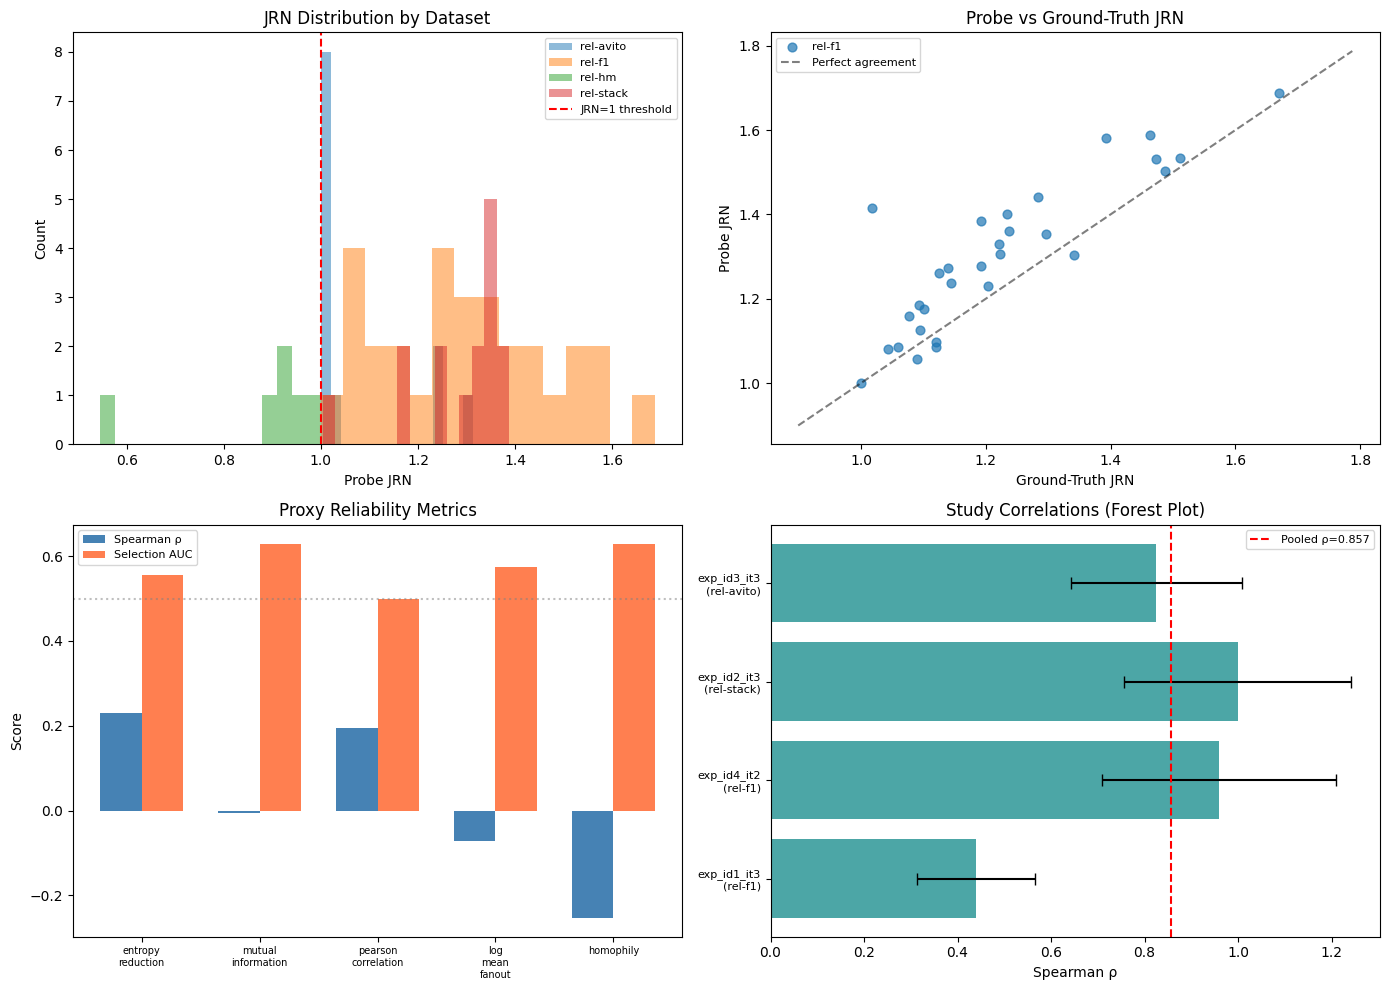


Figure saved to meta_analysis_results.png


In [14]:
# ── Results Summary Table ──
print("=" * 70)
print("KEY RESULTS SUMMARY")
print("=" * 70)
summary = {
    "Total pooled measurements": pooled_metrics["total_pooled_measurements"],
    "Mean JRN (pooled)": f"{pooled_metrics['jrn_mean_pooled']:.4f}",
    "Fraction beneficial (JRN>1)": f"{pooled_metrics['fraction_beneficial']:.4f}",
    "GT pairs": gt_metrics.get("n_gt_pairs", 0),
    "Sign agreement rate": f"{gt_metrics.get('overall_sign_agreement_rate', 0):.4f}",
    "Median abs error": f"{gt_metrics.get('overall_median_abs_error', 0):.4f}",
    "Meta-model R² (LODO-CV)": f"{meta_model['eval_meta_model_r2_loocv']:.4f}",
    "Decision rule accuracy": f"{rules['eval_rule_accuracy']:.4f}",
    "Proxy selection tree acc": f"{decision_tree['eval_decision_tree_accuracy']:.4f}",
    "I² overall": f"{heterogeneity['eval_I2_overall']:.1f}%",
    "Cochran's Q": f"{heterogeneity['eval_Q_statistic']:.2f}",
    "τ²": f"{heterogeneity['eval_tau2']:.4f}",
}
for k, v in summary.items():
    print(f"  {k:35s}: {v}")
print("=" * 70)

# ── Visualization ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: JRN Distribution by Dataset
ax = axes[0, 0]
for ds_name in sorted(df["dataset"].unique()):
    ds_jrn = df[df["dataset"] == ds_name]["probe_jrn"].dropna()
    ax.hist(ds_jrn, bins=15, alpha=0.5, label=ds_name)
ax.axvline(x=1.0, color="red", linestyle="--", linewidth=1.5, label="JRN=1 threshold")
ax.set_xlabel("Probe JRN")
ax.set_ylabel("Count")
ax.set_title("JRN Distribution by Dataset")
ax.legend(fontsize=8)

# Plot 2: Probe vs GT scatter
ax = axes[0, 1]
if len(gt_df) > 0:
    for ds_name in sorted(gt_df["dataset"].unique()):
        sub = gt_df[gt_df["dataset"] == ds_name]
        ax.scatter(sub["gt_jrn"], sub["probe_jrn"], alpha=0.7, label=ds_name, s=40)
    lims = [min(gt_df["gt_jrn"].min(), gt_df["probe_jrn"].min()) - 0.1,
            max(gt_df["gt_jrn"].max(), gt_df["probe_jrn"].max()) + 0.1]
    ax.plot(lims, lims, "k--", alpha=0.5, label="Perfect agreement")
    ax.set_xlabel("Ground-Truth JRN")
    ax.set_ylabel("Probe JRN")
    ax.legend(fontsize=8)
ax.set_title("Probe vs Ground-Truth JRN")

# Plot 3: Proxy Reliability (pooled rho)
ax = axes[1, 0]
if proxy_results:
    pnames = list(proxy_results.keys())
    rhos = [proxy_results[p]["pooled_rho"] for p in pnames]
    aucs = [proxy_results[p]["selection_auc"] for p in pnames]
    x_pos = np.arange(len(pnames))
    width = 0.35
    bars1 = ax.bar(x_pos - width/2, rhos, width, label="Spearman ρ", color="steelblue")
    bars2 = ax.bar(x_pos + width/2, aucs, width, label="Selection AUC", color="coral")
    ax.set_xticks(x_pos)
    ax.set_xticklabels([p.replace("_", "\n") for p in pnames], fontsize=7)
    ax.set_ylabel("Score")
    ax.legend(fontsize=8)
    ax.axhline(y=0.5, color="gray", linestyle=":", alpha=0.5)
ax.set_title("Proxy Reliability Metrics")

# Plot 4: Forest plot of study correlations
ax = axes[1, 1]
if study_correlations:
    labels = [f"{s['experiment']}\n({s['dataset']})" for s in study_correlations]
    rhos = [s["rho"] for s in study_correlations]
    ns = [s["n"] for s in study_correlations]
    # Standard error of Fisher-z
    ses = [1.0 / math.sqrt(max(n - 3, 1)) for n in ns]
    y_pos = np.arange(len(labels))
    ax.barh(y_pos, rhos, xerr=ses, align="center", alpha=0.7, color="teal", capsize=4)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("Spearman ρ")
    ax.axvline(x=heterogeneity.get("pooled_rho", 0), color="red", linestyle="--",
               label=f"Pooled ρ={heterogeneity.get('pooled_rho', 0):.3f}")
    ax.legend(fontsize=8)
ax.set_title("Study Correlations (Forest Plot)")

plt.tight_layout()
plt.savefig("meta_analysis_results.png", dpi=100, bbox_inches="tight")
plt.show()
print("\nFigure saved to meta_analysis_results.png")